--> Total de registros no Dataset Filtrado: 3777
--> Amostras destinadas ao Treino: 3021

Treinando o Modelo 1: LSTM...
Treinando o Modelo 2: ARIMA...
Calculando previsões para 1 passos à frente...
Calculando previsões para 5 passos à frente...
Calculando previsões para 10 passos à frente...
Calculando previsões para 30 passos à frente...
Calculando previsões para 60 passos à frente...


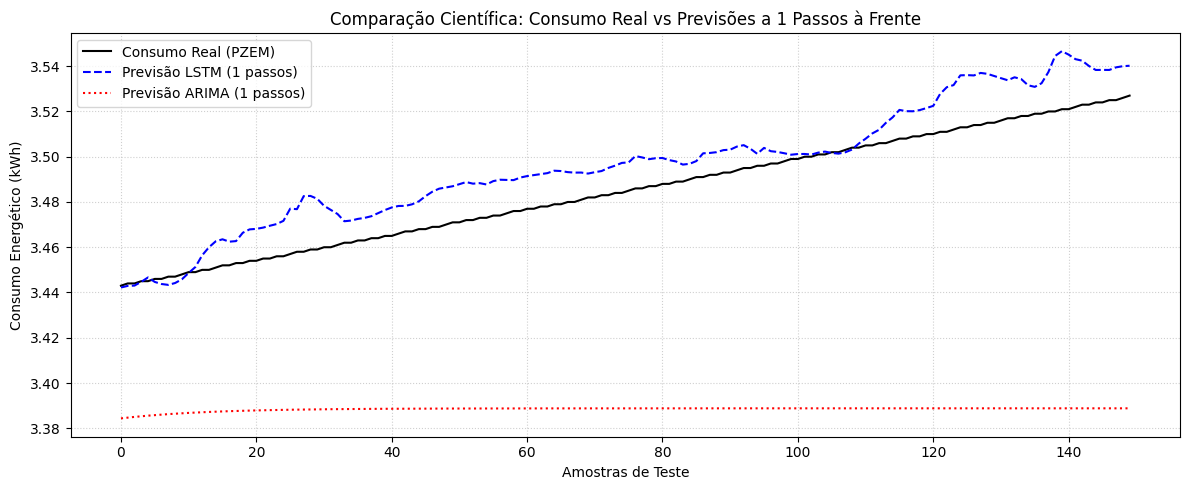

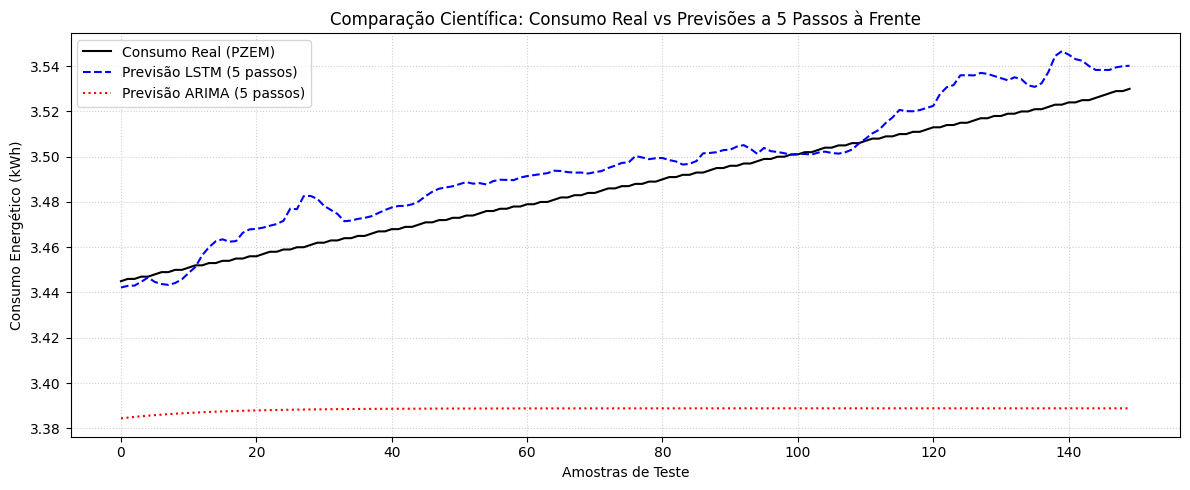

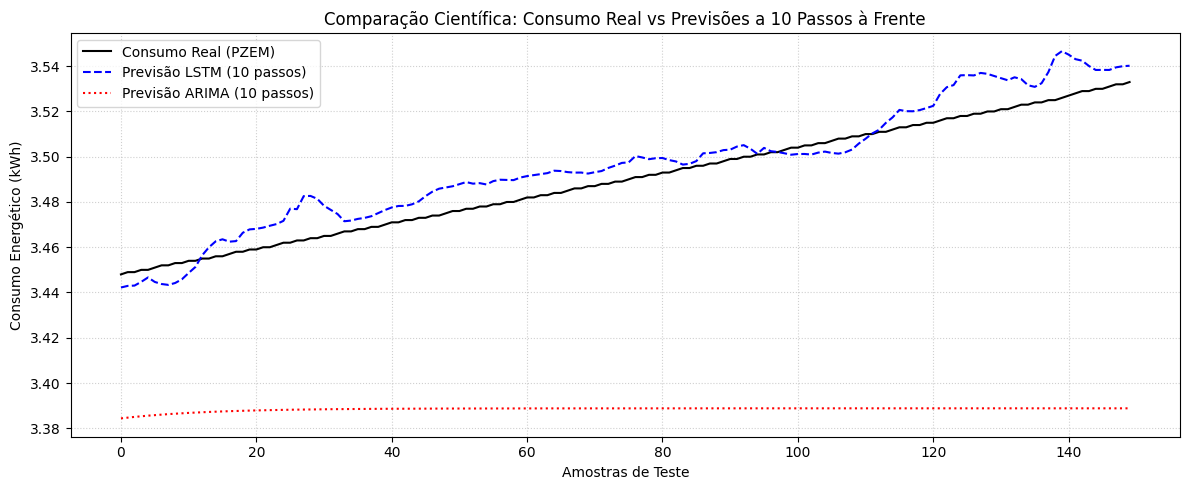

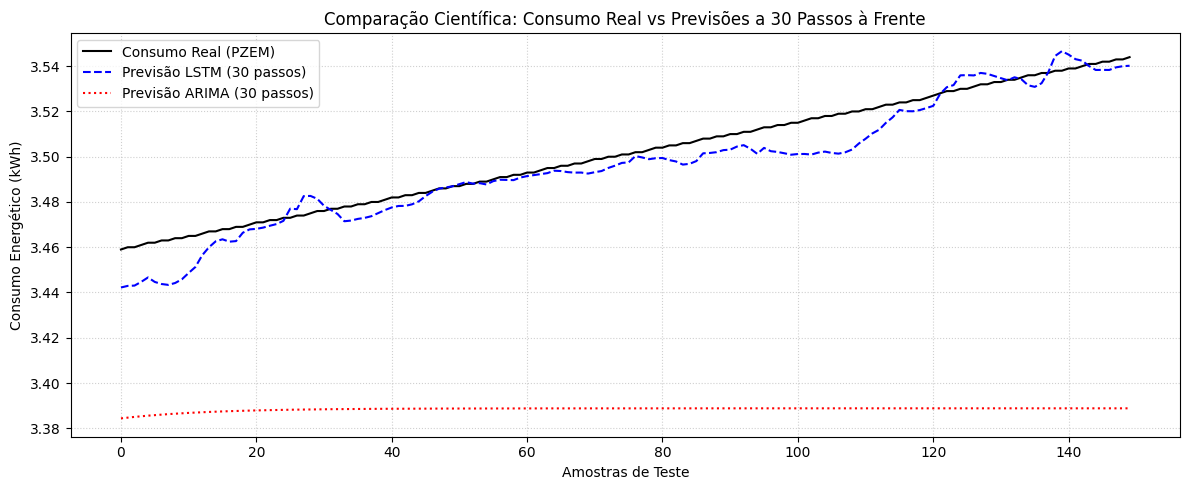

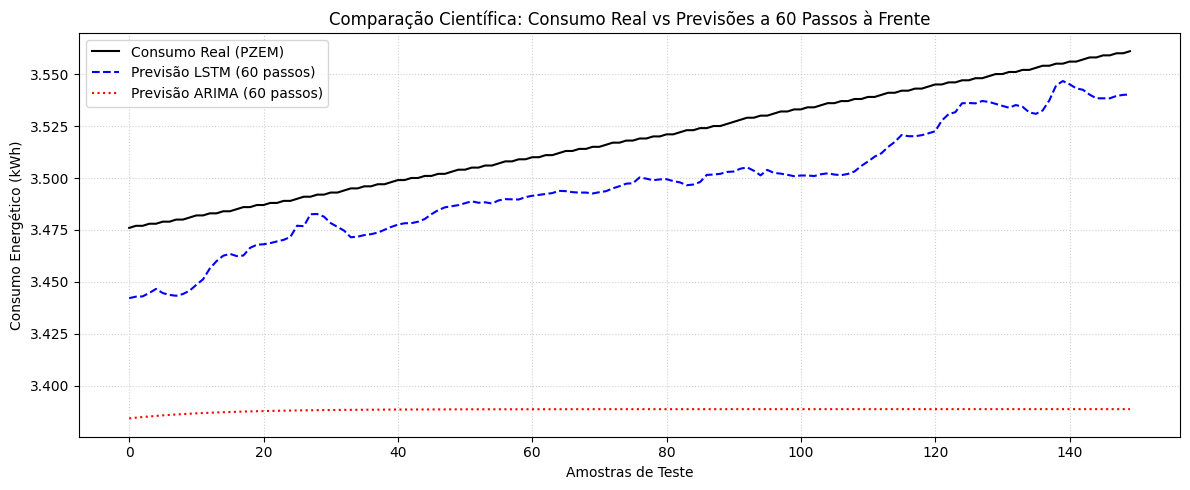

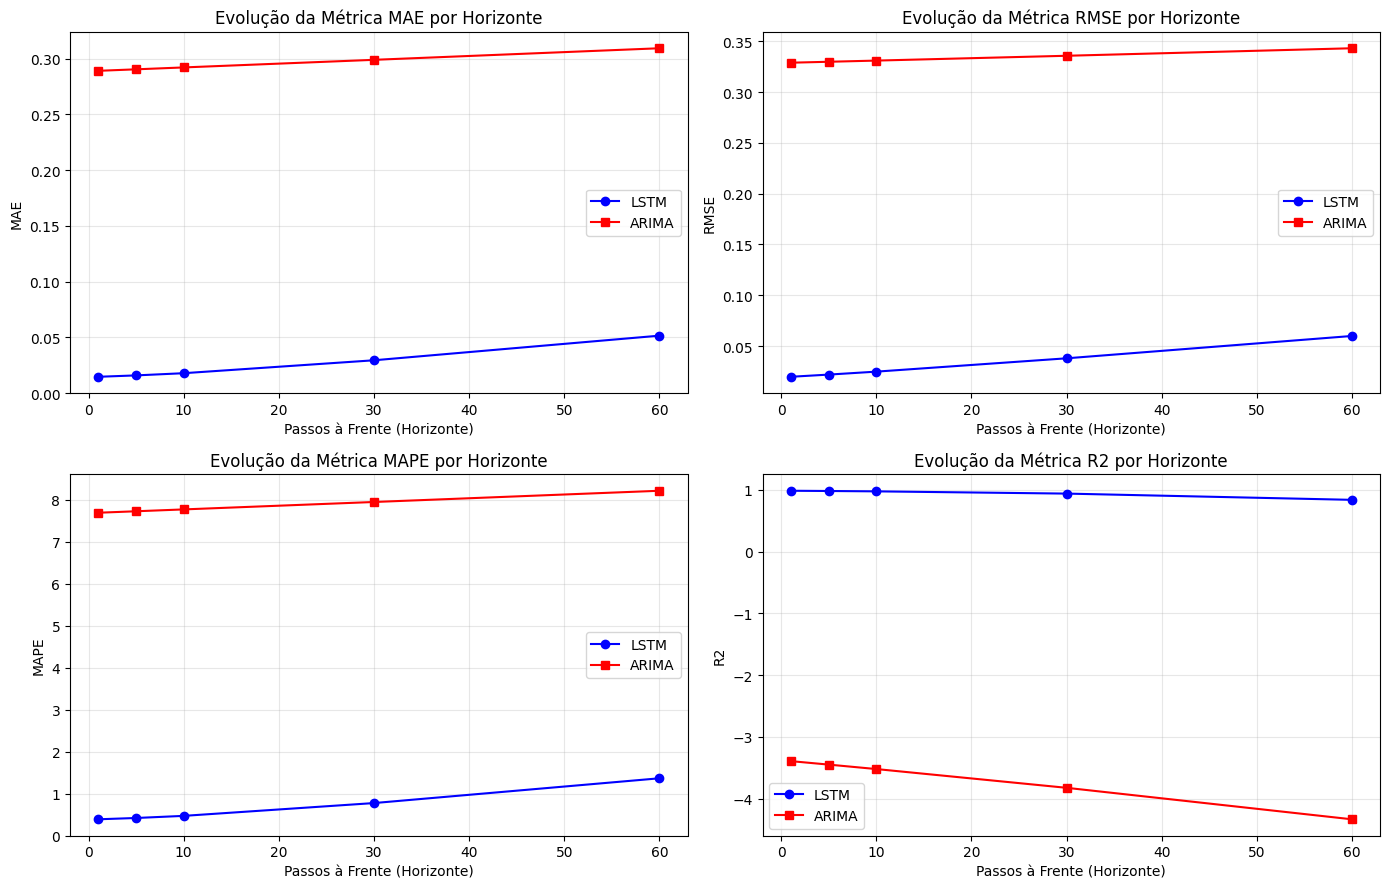


TABELA COMPILADA PARA A SUA DISSERTAÇÃO (RESULTADOS CIENTÍFICOS)

---> HORIZONTE DE PREVISÃO: 1 PASSO(S) À FRENTE
                LSTM     ARIMA
MAE         0.014557  0.289057
RMSE        0.019815  0.328861
MAPE        0.387478  7.693884
R2          0.984060 -3.390283
Tempo_Proc  0.000907  0.000017

---> HORIZONTE DE PREVISÃO: 5 PASSO(S) À FRENTE
                LSTM     ARIMA
MAE         0.015812  0.290409
RMSE        0.021981  0.329784
MAPE        0.418784  7.729094
R2          0.980246 -3.446616
Tempo_Proc  0.000495  0.000017

---> HORIZONTE DE PREVISÃO: 10 PASSO(S) À FRENTE
                LSTM     ARIMA
MAE         0.017784  0.292105
RMSE        0.024883  0.330947
MAPE        0.469104  7.773225
R2          0.974455 -3.518622
Tempo_Proc  0.000375  0.000017

---> HORIZONTE DE PREVISÃO: 30 PASSO(S) À FRENTE
                LSTM     ARIMA
MAE         0.029373  0.298926
RMSE        0.038000  0.335688
MAPE        0.774420  7.950179
R2          0.938207 -3.822160
Tempo_Proc  0.000358  0

In [3]:
import numpy as np
import pandas as pd
import json
import time
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. CARREGAMENTO E TRATAMENTO DOS DADOS (Ref: SCRIPT~1)
# ==========================================
with open('consumo-conciente.json', 'r') as f:
    dados_firebase = json.load(f)

if "leitures" in dados_firebase:
    dados_raiz = dados_firebase["leitures"]  # Mantida a grafia do seu JSON original
elif "leituras" in dados_firebase:
    dados_raiz = dados_firebase["leituras"]
else:
    dados_raiz = dados_firebase

linhas_achatadas = []
for data, horas in dados_raiz.items():
    if isinstance(horas, dict):
        for hora, atributos in horas.items():
            if isinstance(atributos, dict):
                registro = atributos.copy()
                if 'consumo' in registro and 'consumo_total_pzem' not in registro:
                    registro['consumo_total_pzem'] = registro['consumo']
                elif 'consumo_acumulado' in registro and 'consumo_total_pzem' not in registro:
                    registro['consumo_total_pzem'] = registro['consumo_acumulado']
                linhas_achatadas.append(registro)

df = pd.DataFrame(linhas_achatadas)
COLUNAS_MONITORADAS = ['consumo_total_pzem', 'corrente', 'potencia', 'voltagem']

for col in COLUNAS_MONITORADAS:
    if col not in df.columns:
        df[col] = 0.0

df_filtrado = df[COLUNAS_MONITORADAS].dropna().copy()
valores_consumo = df_filtrado['consumo_total_pzem'].values

# Divisão de Treino e Teste (80% / 20%) para validação científica
split = int(len(df_filtrado) * 0.8)
train_data = df_filtrado.iloc[:split]
test_data = df_filtrado.iloc[split:]

# Normalização para a LSTM
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

JANELA = 60
INDICE_CONSUMO = COLUNAS_MONITORADAS.index('consumo_total_pzem')

def criar_janelas_multistep(dados, janela, target_idx):
    X, y = [], []
    for i in range(janela, len(dados)):
        X.append(dados[i-janela:i])
        y.append(dados[i, target_idx])
    return np.array(X), np.array(y)

X_train, y_train = criar_janelas_multistep(train_scaled, JANELA, INDICE_CONSUMO)
X_test, y_test = criar_janelas_multistep(test_scaled, JANELA, INDICE_CONSUMO)

# -------------------------------------------------------------------------
# VALIDAÇÃO DE SEGURANÇA: Evita o IndexError caso os dados sejam insuficientes
# -------------------------------------------------------------------------
print(f"--> Total de registros no Dataset Filtrado: {len(df_filtrado)}")
print(f"--> Amostras destinadas ao Treino: {len(train_scaled)}")

if X_train.ndim < 3 or X_train.shape[0] == 0:
    raise ValueError(
        f"\n[ERRO DE DADOS] O array X_train ficou vazio (Shape atual: {X_train.shape}).\n"
        f"Isso ocorre porque o total de amostras de treino ({len(train_scaled)}) é menor ou igual "
        f"ao tamanho da JANELA ({JANELA}).\n"
        f"SOLUÇÃO: Diminua o valor da variável 'JANELA' no topo do script (ex: JANELA = 10) "
        f"ou insira mais registros no seu arquivo JSON."
    )
# -------------------------------------------------------------------------

# ==========================================
# 2. CONSTRUÇÃO E TREINAMENTO DA LSTM
# ==========================================
print("\nTreinando o Modelo 1: LSTM...")
start_lstm_train = time.time()

model_lstm = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mean_squared_error')
model_lstm.fit(X_train, y_train, batch_size=32, epochs=15, verbose=0)

tempo_treino_lstm = time.time() - start_lstm_train

# ==========================================
# 3. CONSTRUÇÃO E TREINAMENTO DO ARIMA
# ==========================================
print("Treinando o Modelo 2: ARIMA...")
start_arima_train = time.time()
# Usando a série univariada do consumo (dados reais de treino)
model_arima_fit = ARIMA(train_data['consumo_total_pzem'].values, order=(2, 1, 2)).fit()
tempo_treino_arima = time.time() - start_arima_train

# ==========================================
# 4. AVALIAÇÃO MULTI-PASSO (1, 5, 10, 30, 60 passos)
# ==========================================
passos_previsao = [1, 5, 10, 30, 60]
resultados_metricas = {}

def calcular_mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    idx = y_true != 0
    return np.mean(np.abs((y_true[idx] - y_pred[idx]) / y_true[idx])) * 100

for passos in passos_previsao:
    print(f"Calculando previsões para {passos} passos à frente...")

    # --- PREVISÃO REAL VS TARGETS CORRESPONDENTES ---
    ajuste = passos - 1
    if ajuste == 0:
        y_real_real = test_data['consumo_total_pzem'].values[JANELA:]
        X_test_in = X_test
    else:
        y_real_real = test_data['consumo_total_pzem'].values[JANELA + ajuste:]
        X_test_in = X_test[:-ajuste]

    # Se o horizonte de passos for maior do que o tamanho do conjunto de teste, pula para evitar erros
    if len(X_test_in) == 0 or len(y_real_real) == 0:
        print(f"  -> Quantidade de dados em teste insuficiente para avaliar {passos} passos.")
        continue

    # --- PREDIÇÕES LSTM ---
    start_inf_lstm = time.time()
    preds_lstm_scaled = model_lstm.predict(X_test_in, verbose=0)

    # Inverter normalização apenas para a coluna de consumo
    dummy = np.zeros((len(preds_lstm_scaled), len(COLUNAS_MONITORADAS)))
    dummy[:, INDICE_CONSUMO] = preds_lstm_scaled.flatten()
    preds_lstm = scaler.inverse_transform(dummy)[:, INDICE_CONSUMO]
    tempo_inf_lstm = (time.time() - start_inf_lstm) / len(X_test_in)

    # --- PREDIÇÕES ARIMA ---
    start_inf_arima = time.time()
    arima_res = model_arima_fit
    preds_arima = arima_res.forecast(steps=len(y_real_real))
    tempo_inf_arima = (time.time() - start_inf_arima) / len(y_real_real)

    # Limitar tamanhos para garantir alinhamento perfeito
    min_len = min(len(y_real_real), len(preds_lstm), len(preds_arima))
    y_true = y_real_real[:min_len]
    p_lstm = preds_lstm[:min_len]
    p_arima = preds_arima[:min_len]

    # Métricas
    resultados_metricas[passos] = {
        'LSTM': {
            'MAE': mean_absolute_error(y_true, p_lstm),
            'RMSE': np.sqrt(mean_squared_error(y_true, p_lstm)),
            'MAPE': calcular_mape(y_true, p_lstm),
            'R2': r2_score(y_true, p_lstm),
            'Tempo_Proc': tempo_inf_lstm
        },
        'ARIMA': {
            'MAE': mean_absolute_error(y_true, p_arima),
            'RMSE': np.sqrt(mean_squared_error(y_true, p_arima)),
            'MAPE': calcular_mape(y_true, p_arima),
            'R2': r2_score(y_true, p_arima),
            'Tempo_Proc': tempo_inf_arima
        },
        'dados_grafico': (y_true, p_lstm, p_arima)
    }

# ==========================================
# 5. GERAÇÃO DOS GRÁFICOS DO MODELO
# ==========================================
# Gráfico 1: Comparação de Desempenho Temporal
for p in resultados_metricas.keys():
    y_true, p_lstm, p_arima = resultados_metricas[p]['dados_grafico']
    plt.figure(figsize=(12, 5))
    plt.plot(y_true[:150], label='Consumo Real (PZEM)', color='black', lw=1.5)
    plt.plot(p_lstm[:150], label=f'Previsão LSTM ({p} passos)', color='blue', linestyle='--')
    plt.plot(p_arima[:150], label=f'Previsão ARIMA ({p} passos)', color='red', linestyle=':')
    plt.title(f'Comparação Científica: Consumo Real vs Previsões a {p} Passos à Frente')
    plt.xlabel('Amostras de Teste')
    plt.ylabel('Consumo Energético (kWh)')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Gráfico 2: Evolução das Métricas pelo Horizonte de Previsão
if resultados_metricas:
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    metricas_lista = ['MAE', 'RMSE', 'MAPE', 'R2']
    passos_efetivos = list(resultados_metricas.keys())

    for idx, met in enumerate(metricas_lista):
        ax = axes[idx//2, idx%2]
        valores_lstm = [resultados_metricas[p]['LSTM'][met] for p in passos_efetivos]
        valores_arima = [resultados_metricas[p]['ARIMA'][met] for p in passos_efetivos]
        ax.plot(passos_efetivos, valores_lstm, marker='o', color='blue', label='LSTM')
        ax.plot(passos_efetivos, valores_arima, marker='s', color='red', label='ARIMA')
        ax.set_title(f'Evolução da Métrica {met} por Horizonte')
        ax.set_xlabel('Passos à Frente (Horizonte)')
        ax.set_ylabel(met)
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ==========================================
# 6. APRESENTAÇÃO E TABELA COMPARATIVA FINAL
# ==========================================
print("\n" + "="*80)
print("TABELA COMPILADA PARA A SUA DISSERTAÇÃO (RESULTADOS CIENTÍFICOS)")
print("="*80)
for p in resultados_metricas.keys():
    print(f"\n---> HORIZONTE DE PREVISÃO: {p} PASSO(S) À FRENTE")

    # RESOLVIDO: Isola apenas os dados tabulares estruturados antes de chamar o DataFrame
    dados_tabela = {
        'LSTM': resultados_metricas[p]['LSTM'],
        'ARIMA': resultados_metricas[p]['ARIMA']
    }

    df_res = pd.DataFrame(dados_tabela)
    print(df_res.to_string())
print("\n" + "="*80)